[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/dkaratzas/DL2022-23/blob/main/Problems%208%20-%20RNNs/P8_RNNs.ipynb)

# Text generation with an RNN

In this notebook we will learn how to generate text with a Recurrent Neural Network.

We will work with a dataset of Shakespeare's writing from Andrej Karpathy's article [The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/).

Given a sequence of characters from this data (for example "Shakespear"), we will train a model to predict the next character in the sequence ("e"). Longer sequences of text can be generated by calling the model repeatedly.

### Import the necessary modules

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, Dataset

import matplotlib.pyplot as plt
from collections import Counter
import time
import os
import copy
print("PyTorch Version: ",torch.__version__)

PyTorch Version:  2.2.1+cu121


In [ ]:
#If this cell fails you need to change the runtime of your colab notebook to GPU
# Go to Runtime -> Change Runtime Type and select GPU
assert torch.cuda.is_available(), "GPU is not enabled"

#  use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Download the Shakespeare dataset

In [ ]:
! wget https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt

--2024-04-24 00:54:22--  https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.251.2.207, 2607:f8b0:4023:c06::cf, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘shakespeare.txt.1’

shakespeare.txt.1   100%[===================>]   1.06M  --.-KB/s    in 0.006s  

2024-04-24 00:54:22 (177 MB/s) - ‘shakespeare.txt.1’ saved [1115394/1115394]



###  Create a dataset class

For training we need a dataset of (input, label) pairs. Where input and label are sequences of characters. At each time step the input is the current character and the label is the next character. For example:

```
input = ['S', 'h', 'a', 'k', 'e', 's', 'p', 'e', 'a', 'r']
label = ['h', 'a', 'k', 'e', 's', 'p', 'e', 'a', 'r', 'e']
 ```

Actually we will vectorize the characters to convert them into numerical values.

```
input = [44, 7, 0, 10, 4, 18, 15, 4, 0, 17]
label = [7, 0, 10, 4, 18, 15, 4, 0, 17, 4]
```

where each integer value is a class label, and the number of classes is the number of unique characters in our training data (our vocabulary size).

In [ ]:
Dataset?

In [ ]:
class DatasetFromTextFile(Dataset):
    def __init__(self, filename, sequence_length):
        self.filename = filename
        self.sequence_length = sequence_length

        # The whole sequence of characters in the text file (including characters like the end of line character '\n', punctuation marks, etc.)
        self.chars = self.load_chars()
        # The list of unique characters (our vocabulary)
        self.uniq_chars = self.get_uniq_chars()

        # A dictionary with indices as keys and characters as values
        self.index_to_char = {index: char for index, char in enumerate(self.uniq_chars)}
        # A dictionary with characters as keys and indices as values
        self.char_to_index = {char: index for index, char in enumerate(self.uniq_chars)}

        # The whole sequence of character indexes
        # We want to vectorize our text using one-hot vectors at character level
        # But instead of using the one-hot vector we just keep the index of the 1 value
        self.chars_indices = [self.char_to_index[w] for w in self.chars]

        # Split the sequence into chunks of `sequence_length` characters
        # `x` is the input to the model and `y` is the output of the model
        # `y` is the same seuqence as `x` but one character shifted to the right.
        self.x, self.y = self.get_data()

    def load_chars(self):
        with open(self.filename) as fp:
            text = fp.read()
        print(f'Length of text: {len(text)} characters')
        return text

    def get_uniq_chars(self):
        char_counts = Counter(self.chars)
        uniq_chars = sorted(char_counts, key=char_counts.get, reverse=True)
        print(f'Unique characters (vocabulary size): {len(uniq_chars)}')
        return uniq_chars

    def get_data(self):
        x,y = [], []
        for index in range(0, len(self.chars_indices)-self.sequence_length, self.sequence_length):
            x.append(np.array(self.chars_indices[index:index+self.sequence_length]))
            y.append(np.array(self.chars_indices[index+1:index+self.sequence_length+1]))

        return  torch.from_numpy(np.array(x)), torch.from_numpy(np.array(y)).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        assert ((idx >= 0) & (idx < len(self.y))), "Dataset index out of range"
        return self.x[idx], self.y[idx]

Now we can use [`torch.utils.data.Dataloader`](https://pytorch.org/docs/stable/data.html) class to create the PyTorch dataloader.

In [ ]:
# Create the dataset
sequence_length = 100
ShakespeareDataset = DatasetFromTextFile('shakespeare.txt', sequence_length)

print(f'We have {ShakespeareDataset.x.shape[0]} input sequence samples of length {ShakespeareDataset.x.shape[1]} \
and {ShakespeareDataset.y.shape[0]} label sequences of length {ShakespeareDataset.y.shape[1]}')

# Create the Torch DataLoader
batch_size = 64
train_loader = DataLoader(ShakespeareDataset, shuffle=True, batch_size=batch_size, drop_last=True)

Length of text: 1115394 characters
Unique characters (vocabulary size): 65
We have 11153 input sequence samples of length 100 and 11153 label sequences of length 100


## Build the model

Our model has three layers:

* `torch.nn.Embedding`: The input layer. A trainable lookup table that will map each character-ID (class ID) to a dense vector with `embedding_dim` dimensions;
* `torch.nn.GRU`: A type of RNN with `hidden_dim` units
* `torch.nn.Linear`: The output layer, with number of outputs as our vocabulary size (`len(dataset.uniq_chars)`). It outputs one logit for each character in the vocabulary. These are the log-likelihood of each character according to the model.


For each character the model looks up the embedding, runs the GRU one timestep with the embedding as input, and applies the dense layer to generate logits predicting the log-likelihood of the next character:

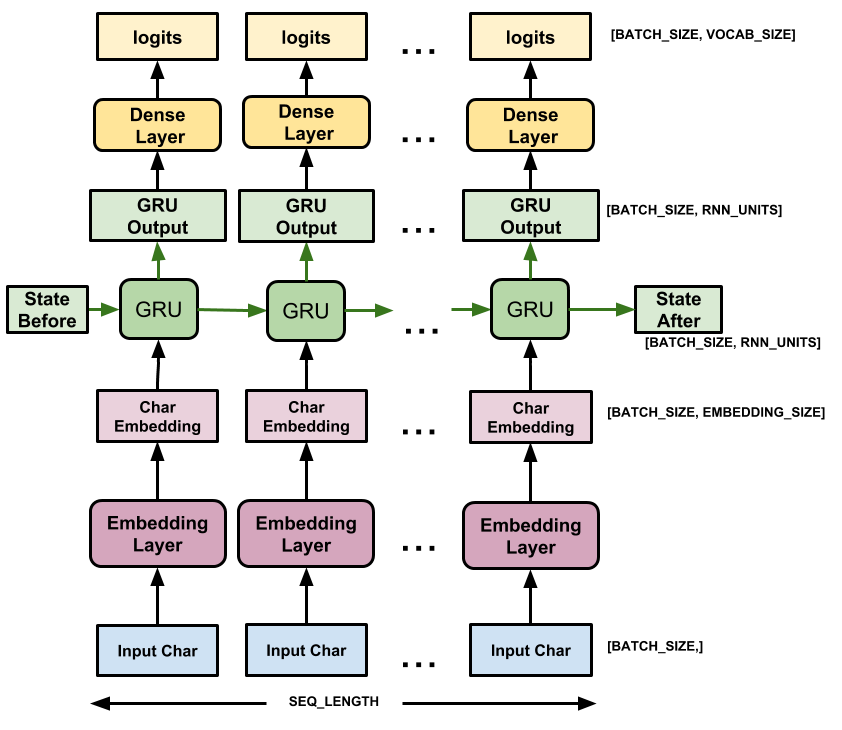

Image source: http://www.tensorflow.org

<span style="color:blue">
    
**Exercise 1:** Complete the code of the `Model` class. You need to embed your input using an `nn.Embedding` layer, create a GRU with `n_layers`, and then compute the output logits.
    
</span>

In [ ]:
class Model(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob=0.):
        super(Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        # YOUR CODE HERE
        self.embedding = torch.nn.Embedding(num_embeddings = input_dim, embedding_dim = embedding_dim)
        self.gru = torch.nn.GRU(input_size = embedding_dim, hidden_size = hidden_dim, num_layers = n_layers, batch_first=True, bidirectional = False)
        self.fc = torch.nn.Linear(in_features = hidden_dim, out_features = output_dim)


    def forward(self, x, h):
        emb = self.embedding(x)
        out, h = self.gru(emb, h)
        out = self.fc(out)
        return out, h

    def init_hidden(self, batch_size):
        " Initialize the hidden state of the RNN to zeros"
        hidden = nn.Parameter(torch.zeros(self.n_layers, batch_size, self.hidden_dim))
        return hidden

Now we can instantiate the model as follows:

In [ ]:
input_dim = len(ShakespeareDataset.uniq_chars)
embedding_dim = 300
hidden_dim = 1024
output_dim = len(ShakespeareDataset.uniq_chars)
n_layers = 2
drop_prob = 0.2

model = Model(input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob).to(device)

print(model)

Model(
  (embedding): Embedding(65, 300)
  (gru): GRU(300, 1024, num_layers=2, batch_first=True)
  (fc): Linear(in_features=1024, out_features=65, bias=True)
)


## Quick Experiment

Let's create a string and pass it through our model

In [ ]:
data = torch.tensor([ShakespeareDataset.char_to_index[w] for w in "Hello"])
print(data.shape)

torch.Size([5])


Our model expects a batch. We will create a batch of 1, using this one data point we have created

In [ ]:
data = data.unsqueeze(0) # this adds one more dimension (the batch one) to our data
print(data.shape)

torch.Size([1, 5])


Time to pass this through our model. To do so, we need to (1) move our data to the same device like the model and (2) initialise the state of our RNN

In [ ]:
data = data.to(device)
state = model.init_hidden(batch_size = 1) # remember that we will use just a single data point jere
state = state.to(device)
out, state = model(data, state) # The forward pass expects the current state as an argument, and returns the updated state in the output

print(out.shape)

torch.Size([1, 5, 65])


Our output returns 65 probability values for each character... We need to find which one is the maximum probability for each position, and convert it to the corresponding character

In [ ]:
_, idxs = torch.max(out[0], dim = 1)

print([ShakespeareDataset.index_to_char[int(c)] for c in idxs])

['N', '-', 'D', 'D', 'D']


As expected both inputs and outputs have the same shape, and the predicted characters are just random since the model is not trained yet.

## Train the model

Training a language model is essentially a classification problem. Given the previous RNN state, and the input character at this time step, predict the class of the next character.

<span style="color:blue">

**Exercise 2:** which loss function do you think we shall use to train our model?

$\to$ The cross entropy loss (since we are doing a multi-class classification, with Softmax)
    
</span>

In [ ]:
def train(dataloader, model, batch_size, sequence_length, num_epochs):
    model.train()

    criterion =  nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    for epoch in range(num_epochs):

        for batch, (x, y) in enumerate(dataloader):
            state = model.init_hidden(batch_size) # Start with a new state in each batch
            state = state.to(device)

            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()

            y_pred, state = model(x, state)
            loss = criterion(y_pred.transpose(1, 2), y)

            loss.backward()
            optimizer.step()

            if batch%30 == 0:
                print({ 'epoch': epoch, 'batch': batch, 'loss': loss.item() })
                losses.append(loss.item())
    return losses

Now train the model for 20 epochs and visualize the training loss curve.

In [ ]:
num_epochs = 20

losses = train(train_loader, model, batch_size, sequence_length, num_epochs)

{'epoch': 0, 'batch': 0, 'loss': 4.177779674530029}
{'epoch': 0, 'batch': 30, 'loss': 2.219489812850952}
{'epoch': 0, 'batch': 60, 'loss': 1.954404592514038}
{'epoch': 0, 'batch': 90, 'loss': 1.7880576848983765}
{'epoch': 0, 'batch': 120, 'loss': 1.6521594524383545}
{'epoch': 0, 'batch': 150, 'loss': 1.603381633758545}
{'epoch': 1, 'batch': 0, 'loss': 1.537624716758728}
{'epoch': 1, 'batch': 30, 'loss': 1.4642375707626343}
{'epoch': 1, 'batch': 60, 'loss': 1.470499873161316}
{'epoch': 1, 'batch': 90, 'loss': 1.4302377700805664}
{'epoch': 1, 'batch': 120, 'loss': 1.4198721647262573}
{'epoch': 1, 'batch': 150, 'loss': 1.4263243675231934}
{'epoch': 2, 'batch': 0, 'loss': 1.3456048965454102}
{'epoch': 2, 'batch': 30, 'loss': 1.3373030424118042}
{'epoch': 2, 'batch': 60, 'loss': 1.359804630279541}
{'epoch': 2, 'batch': 90, 'loss': 1.3419761657714844}
{'epoch': 2, 'batch': 120, 'loss': 1.3588656187057495}
{'epoch': 2, 'batch': 150, 'loss': 1.3006503582000732}
{'epoch': 3, 'batch': 0, 'loss':

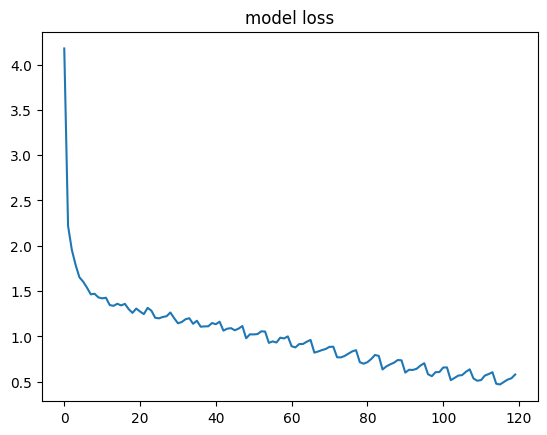

In [ ]:
# Visualize the loss evolution during training
plt.plot(losses)
plt.title('model loss')
plt.show()

## Try the trained model

Let's try again to predict some characters given the input sentence 'ROMEO:'. Now the predicted characters should be much better.

In [ ]:
with torch.no_grad():
    input_str = 'ROMEO:'

    state = model.init_hidden(batch_size=1)
    state = state.to(device)
    data = torch.tensor([[ShakespeareDataset.char_to_index[char] for char in input_str]]).to(device)
    output, state = model(data, state)

    _, predicted_idxs = torch.max(output[0], dim = 1)
    predicted_idxs = predicted_idxs.cpu().numpy()

    predicted_str = ''.join([ShakespeareDataset.index_to_char[idx] for idx in predicted_idxs])

    print(f'Input shape: {data.size()}')
    print(f'Output shape: {data.size()}')
    print(f'Input string: {input_str}')
    print(f'Output string: {predicted_str}')

Input shape: torch.Size([1, 6])
Output shape: torch.Size([1, 6])
Input string: ROMEO:
Output string: IMEO:



## Generate new text

In [ ]:
def predict(dataset, model, text, next_chars=1000):
    model.eval()

    chars = [char for char in text]
    state = model.init_hidden(1)
    state = state.to(device)

    # we start by feeding all the input characters to our model
    x = torch.tensor([dataset.char_to_index[char] for char in chars])
    x = x.unsqueeze(0) # create a batch of 1
    x = x.to(device)

    for i in range(0, next_chars):

        y_pred, state = model(x, state)

        last_char_logits = y_pred[0][-1]
        p = torch.nn.functional.softmax(last_char_logits, dim=0).detach().cpu().numpy()
        char_index = np.random.choice(len(last_char_logits), p=p)
        chars.append(dataset.index_to_char[char_index])

        # the output of the model (a single character index) becomes the input at next iteration
        x = torch.tensor([[char_index]])
        x = x.to(device)

    return chars

predicted = predict(ShakespeareDataset, model,'ROMEO:')
print(''.join(predicted))

ROMEO:
Shall the king extremising on an ind feir course,
Seize one to the Duke of Hereford, and willing something show
That hour but milk out any child by him.

HENRY BOLINGBROKE:
Call forth Bagot.
Now, fellow,
What news it?

CORIOLANUS:
What must be band?
If you were born so high abroad as I have fought
With a surmitable; something stain'd with Bolingbroke's,
And men may tensier than a younger.

LUCENTIO:
What said our part? Corse come you now! what noise?
Then, since it like me from the honour of his hand,
That he would laugh again in the suburber mother;
Nothing still before a respected cousin,
On your commonwealth from his word is call'd us.

AUFIDIUS:
Read it so;
I am a feather for a bury to aufidius,
Till he her for you: pray, get you home; be not advance
The country he's confess'd it. Sir, that's a merry one.

PETRUCHIO:
Now, by being hope, here's fled from her when lady, and yet you'll descend.

PAULINA:
Good my liege, I know what I meant by an
undischiof: for the what we will 

While some of the sentences are grammatically correct, most do not make sense. The model has not learned the meaning of words (we would need a much larger corpus for that, and probably a word level language model), but consider the following:

* The model is character-based. When training started, the model did not know how to spell an English word, or that words were even a unit of text. Now it does a pretty decent job on spelling.

* The structure of the output resembles a play, blocks of text generally begin with a speaker name, in all capital letters similar to the dataset.

* The model is trained on small batches of text (100 characters each), and is still able to generate a longer sequence of text with coherent structure.

# Homework

<span style="color:blue">
    
**Exercise 3:** Build two new models: one using Simple RNN cells (torch.nn.RNN) instead of GRUs(torch.nn.RNN), and the other using LSTMs (torch.nn.LSTM). Train all three models (GRU, LSTM, SimpleRNN) for 30 epochs and compare the loss curves. You can optionally try different configurations: embedding dimension, hidden layers dimensions, number of layers, etc.
    
</span>

In [ ]:
# GRU
num_epochs = 30

losses_GRU = train(train_loader, model, batch_size, sequence_length, num_epochs)

{'epoch': 0, 'batch': 0, 'loss': 4.176522731781006}
{'epoch': 0, 'batch': 30, 'loss': 2.2526588439941406}
{'epoch': 0, 'batch': 60, 'loss': 1.9289648532867432}
{'epoch': 0, 'batch': 90, 'loss': 1.7788255214691162}
{'epoch': 0, 'batch': 120, 'loss': 1.6895267963409424}
{'epoch': 0, 'batch': 150, 'loss': 1.586256504058838}
{'epoch': 1, 'batch': 0, 'loss': 1.50981867313385}
{'epoch': 1, 'batch': 30, 'loss': 1.4492180347442627}
{'epoch': 1, 'batch': 60, 'loss': 1.4538160562515259}
{'epoch': 1, 'batch': 90, 'loss': 1.4657472372055054}
{'epoch': 1, 'batch': 120, 'loss': 1.3952903747558594}
{'epoch': 1, 'batch': 150, 'loss': 1.416853427886963}
{'epoch': 2, 'batch': 0, 'loss': 1.3755205869674683}
{'epoch': 2, 'batch': 30, 'loss': 1.3191992044448853}
{'epoch': 2, 'batch': 60, 'loss': 1.338541865348816}
{'epoch': 2, 'batch': 90, 'loss': 1.3260083198547363}
{'epoch': 2, 'batch': 120, 'loss': 1.3118221759796143}
{'epoch': 2, 'batch': 150, 'loss': 1.3418291807174683}
{'epoch': 3, 'batch': 0, 'loss'

In [ ]:
# RNN
class ModelRNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob=0.):
        super(ModelRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        # YOUR CODE HERE
        self.embedding = torch.nn.Embedding(num_embeddings = input_dim, embedding_dim = embedding_dim)
        self.rnn = torch.nn.RNN(input_size = embedding_dim, hidden_size = hidden_dim, num_layers = n_layers, batch_first=True)
        self.fc = torch.nn.Linear(in_features = hidden_dim, out_features = output_dim)


    def forward(self, x, h):
        emb = self.embedding(x)
        out, h = self.rnn(emb, h)
        out = self.fc(out)
        return out, h

    def init_hidden(self, batch_size):
        " Initialize the hidden state of the RNN to zeros"
        hidden = nn.Parameter(torch.zeros(self.n_layers, batch_size, self.hidden_dim))
        return hidden

In [ ]:
modelRNN = ModelRNN(input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob).to(device)
print(modelRNN)

losses_RNN = train(train_loader, modelRNN, batch_size, sequence_length, num_epochs)

ModelRNN(
  (embedding): Embedding(65, 300)
  (rnn): RNN(300, 1024, num_layers=2, batch_first=True)
  (fc): Linear(in_features=1024, out_features=65, bias=True)
)
{'epoch': 0, 'batch': 0, 'loss': 4.178610324859619}
{'epoch': 0, 'batch': 30, 'loss': 2.2354190349578857}
{'epoch': 0, 'batch': 60, 'loss': 1.9857133626937866}
{'epoch': 0, 'batch': 90, 'loss': 1.8662419319152832}
{'epoch': 0, 'batch': 120, 'loss': 1.7642877101898193}
{'epoch': 0, 'batch': 150, 'loss': 1.660097599029541}
{'epoch': 1, 'batch': 0, 'loss': 1.6465531587600708}
{'epoch': 1, 'batch': 30, 'loss': 1.6297271251678467}
{'epoch': 1, 'batch': 60, 'loss': 1.5537103414535522}
{'epoch': 1, 'batch': 90, 'loss': 1.5416592359542847}
{'epoch': 1, 'batch': 120, 'loss': 1.5052014589309692}
{'epoch': 1, 'batch': 150, 'loss': 1.5653297901153564}
{'epoch': 2, 'batch': 0, 'loss': 1.4289497137069702}
{'epoch': 2, 'batch': 30, 'loss': 1.4723153114318848}
{'epoch': 2, 'batch': 60, 'loss': 1.4731073379516602}
{'epoch': 2, 'batch': 90, 'l

In [ ]:
class ModelLSTM(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob=0.):
        super(ModelLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(num_embeddings=input_dim, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x, h):
        emb = self.embedding(x)
        out, h = self.lstm(emb, h)
        out = self.fc(out)
        return out, h

    def init_hidden(self, batch_size):
        # Initialize the hidden state of the LSTM to zeros
        hidden = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
        cell = torch.zeros(self.n_layers, batch_size, self.hidden_dim).to(device)
        return hidden, cell

def trainLSTM(dataloader, model, batch_size, sequence_length, num_epochs):
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    for epoch in range(num_epochs):
        for batch, (x, y) in enumerate(dataloader):
            # Initialize hidden state for each batch
            hidden, cell = model.init_hidden(batch_size)

            # Move tensors to the appropriate device
            x = x.to(device)
            y = y.to(device)
            hidden = hidden.to(device)
            cell = cell.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            y_pred, (hidden, cell) = model(x, (hidden, cell))

            # Compute loss
            loss = criterion(y_pred.transpose(1, 2), y)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()


            # Print every 30 batches
            if batch % 30 == 0:
                print({ 'epoch': epoch, 'batch': batch, 'loss': loss.item() })
                # Track the training loss
                losses.append(loss.item())

    return losses

In [ ]:
modelLSTM = ModelLSTM(input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob).to(device)
print(modelRNN)

losses_LSTM = trainLSTM(train_loader, modelLSTM, batch_size, sequence_length, num_epochs)

ModelRNN(
  (embedding): Embedding(65, 300)
  (rnn): RNN(300, 1024, num_layers=2, batch_first=True)
  (fc): Linear(in_features=1024, out_features=65, bias=True)
)
{'epoch': 0, 'batch': 0, 'loss': 4.174380302429199}
{'epoch': 0, 'batch': 30, 'loss': 2.2977399826049805}
{'epoch': 0, 'batch': 60, 'loss': 1.94919753074646}
{'epoch': 0, 'batch': 90, 'loss': 1.786899447441101}
{'epoch': 0, 'batch': 120, 'loss': 1.6686460971832275}
{'epoch': 0, 'batch': 150, 'loss': 1.6064907312393188}
{'epoch': 1, 'batch': 0, 'loss': 1.5269511938095093}
{'epoch': 1, 'batch': 30, 'loss': 1.4717040061950684}
{'epoch': 1, 'batch': 60, 'loss': 1.4738682508468628}
{'epoch': 1, 'batch': 90, 'loss': 1.4169151782989502}
{'epoch': 1, 'batch': 120, 'loss': 1.3677095174789429}
{'epoch': 1, 'batch': 150, 'loss': 1.4259449243545532}
{'epoch': 2, 'batch': 0, 'loss': 1.3214184045791626}
{'epoch': 2, 'batch': 30, 'loss': 1.2954219579696655}
{'epoch': 2, 'batch': 60, 'loss': 1.3698747158050537}
{'epoch': 2, 'batch': 90, 'los

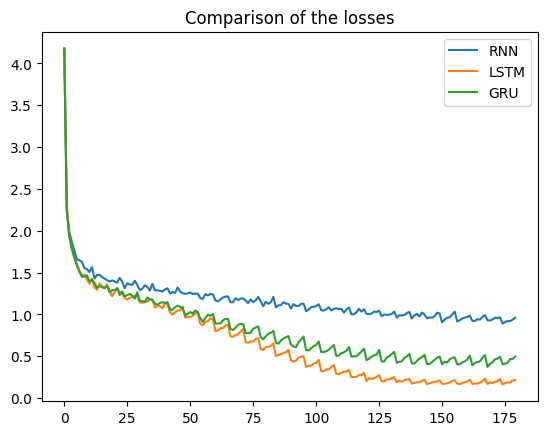

In [ ]:
# Compare the loss evolution
plt.plot(losses_RNN, label='RNN')
plt.plot(losses_LSTM, label='LSTM')
plt.plot(losses_GRU, label='GRU')
plt.title('Comparison of the losses')
plt.legend()
plt.show()

As we can see, the LSTM model seems to be the best one. In fact, its accuracy is significantly smaller than the 2 others, especially at the end of the training.

<span style="color:blue">

**Exercise 4:** Train your best model on a different dataset. Use the 'inaugural' corpus of the [NLTK](https://www.nltk.org/) library. Once trained generate some text with as we did for the model trained on the Shakespeare dataset. Compare the generated texts with both models using the smae "seed" (input) text. What differences do you appreciate? Why are they different?
    
</span>

The Natural Language Toolkit, or more commonly NLTK, is a suite of datasets, libraries and models for symbolic and statistical natural language processing (NLP). The Inaugural Address Corpus contains the US presidential inaugural addresses from 1789 to 2017. The following code loads the 'inaugural' corpus:

In [ ]:
import nltk
nltk.download('inaugural')

inaugural = nltk.corpus.inaugural
text = inaugural.raw()

print(f'Length of text: {len(text)} characters')

Length of text: 807276 characters


[nltk_data] Downloading package inaugural to /root/nltk_data...
[nltk_data]   Package inaugural is already up-to-date!


In [ ]:
class DatasetFromText(Dataset):
    def __init__(self,text, sequence_length):
        self.sequence_length = sequence_length

        # The whole sequence of characters in the text file (including characters like the end of line character '\n', punctuation marks, etc.)
        self.chars = text
        # The list of unique characters (our vocabulary)
        self.uniq_chars = self.get_uniq_chars()

        # A dictionary with indices as keys and characters as values
        self.index_to_char = {index: char for index, char in enumerate(self.uniq_chars)}
        # A dictionary with characters as keys and indices as values
        self.char_to_index = {char: index for index, char in enumerate(self.uniq_chars)}

        # The whole sequence of character indexes
        # We want to vectorize our text using one-hot vectors at character level
        # But instead of using the one-hot vector we just keep the index of the 1 value
        self.chars_indices = [self.char_to_index[w] for w in self.chars]

        # Split the sequence into chunks of `sequence_length` characters
        # `x` is the input to the model and `y` is the output of the model
        # `y` is the same seuqence as `x` but one character shifted to the right.
        self.x, self.y = self.get_data()

    def get_uniq_chars(self):
        char_counts = Counter(self.chars)
        uniq_chars = sorted(char_counts, key=char_counts.get, reverse=True)
        print(f'Unique characters (vocabulary size): {len(uniq_chars)}')
        return uniq_chars

    def get_data(self):
        x,y = [], []
        for index in range(0, len(self.chars_indices)-self.sequence_length, self.sequence_length):
            x.append(np.array(self.chars_indices[index:index+self.sequence_length]))
            y.append(np.array(self.chars_indices[index+1:index+self.sequence_length+1]))

        return  torch.from_numpy(np.array(x)), torch.from_numpy(np.array(y)).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        assert ((idx >= 0) & (idx < len(self.y))), "Dataset index out of range"
        return self.x[idx], self.y[idx]

In [ ]:
# Create the dataset
sequence_length = 100
NLTKDataset = DatasetFromText(text, sequence_length)

print(f'We have {NLTKDataset.x.shape[0]} input sequence samples of length {NLTKDataset.x.shape[1]} \
and {NLTKDataset.y.shape[0]} label sequences of length {NLTKDataset.y.shape[1]}')

# Create the Torch DataLoader
batch_size = 64
train_loader = DataLoader(NLTKDataset, shuffle=True, batch_size=batch_size, drop_last=True)

Unique characters (vocabulary size): 85
We have 8072 input sequence samples of length 100 and 8072 label sequences of length 100


In [ ]:
# Train the best model
input_dim = len(NLTKDataset.uniq_chars)
embedding_dim = 300
hidden_dim = 1024
output_dim = len(NLTKDataset.uniq_chars)
n_layers = 2
drop_prob = 0.2
best_model = ModelLSTM(input_dim, embedding_dim, hidden_dim, output_dim, n_layers, drop_prob).to(device)
print(best_model)

losses_NLTK = trainLSTM(train_loader, best_model, batch_size, sequence_length, num_epochs)

ModelLSTM(
  (embedding): Embedding(85, 300)
  (lstm): LSTM(300, 1024, num_layers=2, batch_first=True)
  (fc): Linear(in_features=1024, out_features=85, bias=True)
)
{'epoch': 0, 'batch': 0, 'loss': 4.437342643737793}
{'epoch': 0, 'batch': 30, 'loss': 2.250579595565796}
{'epoch': 0, 'batch': 60, 'loss': 1.8071426153182983}
{'epoch': 0, 'batch': 90, 'loss': 1.5494171380996704}
{'epoch': 0, 'batch': 120, 'loss': 1.463289737701416}
{'epoch': 1, 'batch': 0, 'loss': 1.4018356800079346}
{'epoch': 1, 'batch': 30, 'loss': 1.3583672046661377}
{'epoch': 1, 'batch': 60, 'loss': 1.2713263034820557}
{'epoch': 1, 'batch': 90, 'loss': 1.282905101776123}
{'epoch': 1, 'batch': 120, 'loss': 1.1849476099014282}
{'epoch': 2, 'batch': 0, 'loss': 1.190494418144226}
{'epoch': 2, 'batch': 30, 'loss': 1.2145084142684937}
{'epoch': 2, 'batch': 60, 'loss': 1.1603773832321167}
{'epoch': 2, 'batch': 90, 'loss': 1.1978057622909546}
{'epoch': 2, 'batch': 120, 'loss': 1.1701600551605225}
{'epoch': 3, 'batch': 0, 'los

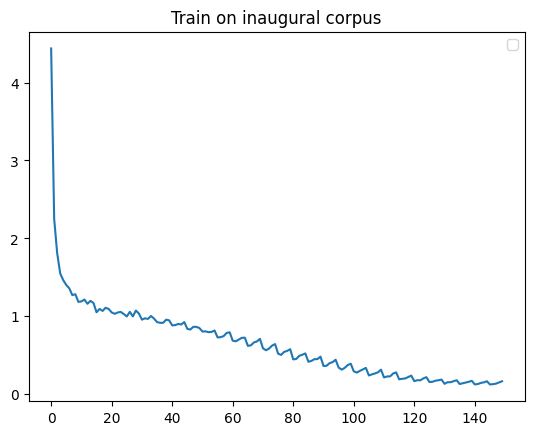

In [ ]:
# Loss evolution
plt.plot(losses_NLTK)
plt.title('Train on inaugural corpus')
plt.legend()
plt.show()

In [ ]:
def predict(dataset, model, text, next_chars=1000):
    model.eval()

    chars = [char for char in text]
    state, cell = model.init_hidden(1)
    state = state.to(device)
    cell = cell.to(device)

    # we start by feeding all the input characters to our model
    x = torch.tensor([dataset.char_to_index[char] for char in chars])
    x = x.unsqueeze(0) # create a batch of 1
    x = x.to(device)

    for i in range(0, next_chars):
        y_pred, (state, cell) = model(x, (state, cell))

        last_char_logits = y_pred[0][-1]
        p = torch.nn.functional.softmax(last_char_logits, dim=0).detach().cpu().numpy()
        char_index = np.random.choice(len(last_char_logits), p=p)
        chars.append(dataset.index_to_char[char_index])

        # the output of the model (a single character index) becomes the input at next iteration
        x = torch.tensor([[char_index]])
        x = x.to(device)

    return chars

# Predictions on Sakespeare dataset
predicted = predict(ShakespeareDataset, modelLSTM,'ROMEO:')
print(''.join(predicted))

ROMEO:
Indeed, it does say this is the right, and he,
A madman's mouth is but a paper
And rapt in secret studies. Thy false use have
I prized in reverence, though he were my wife's honest.

ELANT:
Bring forth that fatal screech-owl to begin his woe:
A pardon as a young man, I'll first,
And that the queen is valuarous days:
But now mischance hath trod my title down,
And that my name forswear thou wilt be married!
My loving lord, I take my leave off ye:
I will revenge his wrong to Lady Bona,
And quit it in the treachery or the thrower-oppreser;
And suffer'd me, the unity that may
Be his concealing able to sleep.

ANTIGONUS:
Call you my heart?

Third Servingman:
Nay, I knew by his face to the will:
He, would you note deny, or I will not cast thou,
Where you were tied in duty, for I cannot counter.
And you were there, they shall not be full-gorged.
My husband is thy lord, this is a sisterhor,
To be your comforter when he is end.

MONTAGUE:
When I am already, I will take it up for
pity: yet

In [ ]:
# Predictions on NLTK dataset
predicted = predict(NLTKDataset, best_model,'ROMEO:')
print(''.join(predicted))

ROMEO:

I shall now proceed to take the oath prescribed by the Constitution has declared through the destiny of my American botth. Our recommendation rests being the rewards of partisan services are fear to be attained in accordance with our institutions and essential to the public business caused at large humanity equally across the hills and plains of the obligations of the United States to support armies and new duties which would result to different States and sections from its dissons -- but we must simply do our best efforts to prozour small, will define our American destiny. And your courage and goodness and love will forgotten no longer departure from that no permanent man must again be remembered as an admonition. The one we are now briefly never before us, who spend it was not waging war, and fighting under the authority of the brotherhood of man, the highest law of all our best remedial lines, but such an appointment. The issues of the office which has been arrested by the s

As we can see, in the first case, the result with the first dataset is in the shape of a theater writting, with characters, denoted in capital letters, while the second dataset leads to a complete text (without the previous shape). We can also note that this second dataset leads to long sentences, which are similar to law descriptions for example (juridic words, with long sentences).

But what we can see is that in both cases, the sentences does not really have any sense. Each sentence can make a bit of sense, but there isn't any really logical link between following sentences.